<h1 style="text-align:center;">Interactive PCA plots of experimental CDRs</h1>

In [94]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
import re

from Bio.PDB import PDBList
from pathlib import Path
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

import pickle
#import MDAnalysis as mda
#from MDAnalysis.coordinates.PDB import PDBWriter
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

std_pal = sns.color_palette("deep")

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pickle

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.lines as mlines
import matplotlib.cm as cm

# PCA on CDRs

In [2]:
def get_chain_sequence(pdb_file, chain_id):
    """
    Get sequence based on chain id.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)

    seq = []
    for res in structure[0][chain_id]: 
        seq.append(seq1(res.get_resname()))

    return "".join(seq)


def extract_cdr3(sequence, min_len=7, max_len=23):
    """
    Extract CDR3 using conserved C (start) and the F/W-GxG motif (end). Ensures min_len <= CDR3 length <= max_len.
    """
    # find all conserved C positions
    c_positions = [m.start() for m in re.finditer("C", sequence)]
    if not c_positions:
        return None

    # try Cs from last to first (most likely real CDR3 start)
    for c_pos in reversed(c_positions):
        subseq = sequence[c_pos:]

        # find all FGXG / WGXG motifs after this C
        matches = list(re.finditer(r"([FW])G.G", subseq))
        if not matches:
            continue

        # check motifs from LAST to FIRST
        for match in reversed(matches):
            end = c_pos + match.start(1) + 1
            cdr3 = sequence[c_pos:end]

            L = len(cdr3)
            if min_len <= L <= max_len:
                return cdr3

    return None

def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}, cdr3_splits=None):
    """
    Extract Cα coordinates for CDRs.
    cdr_dict: {"CDR1A": seq, "CDR2A": seq, "CDR3A": seq, ...}
    cdr3_splits: optional {chain_label: {"cdr3v": seq, "cdr3j": seq}}
                 sub-segments are located by offset from the CDR3 position.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    cdr_coords = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        residues  = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join([seq1(res.get_resname()) for res in residues])
        cdr_coords[chain_label] = {}

        cdr3_start = cdr3_len = None
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            idx = seq.find(cdr_seq)
            if idx == -1:
                print(f"Warning: {cdr_key} not found in chain {chain_id} of {pdb_path}")
                return None
            cdr_coords[chain_label][f"cdr{i}"] = np.array(
                [res["CA"].get_coord() for res in residues[idx:idx + len(cdr_seq)]]
            )
            if i == 3:
                cdr3_start, cdr3_len = idx, len(cdr_seq)

        # CDR3 sub-segments located by offset — no ambiguous search on short seqs
        if cdr3_splits and chain_label in cdr3_splits:
            for seg_name, seg_seq in cdr3_splits[chain_label].items():
                if not seg_seq:
                    continue
                if seg_name == 'cdr3v':
                    start = cdr3_start
                elif seg_name == 'cdr3j':
                    start = cdr3_start + cdr3_len - len(seg_seq)
                else:
                    continue
                cdr_coords[chain_label][seg_name] = np.array(
                    [res["CA"].get_coord() for res in residues[start:start + len(seg_seq)]]
                )

    return cdr_coords


def build_coord_matrix(cdr_coord_dict, min_cdr_lengths):
    """
    Build coordinate matrix with fixed-length CDRs.
    """
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1","cdr2"]:
                coords = cdrs[cdr_name]
                L = min_cdr_lengths[chain][cdr_name]
                # first 2 + last L-2
                selected = np.vstack([coords[:2], coords[-(L-2):]])
                vec.extend(selected.flatten())
            # CDR3: first 5 + last L-5
            coords = cdrs["cdr3"]
            L = min_cdr_lengths[chain]["cdr3"]
            selected = np.vstack([coords[:5], coords[-(L-5):]])
            vec.extend(selected.flatten())
        coord_matrix.append(vec)
    
    return np.array(coord_matrix)


# MixTCRviz colors

In [3]:
# R color name → hex conversion
r_colors = {'grey95': '#F2F2F2', 'grey80': '#CCCCCC', 'grey50': '#808080'}

pch_to_plotly = {21: 'circle', 22: 'square', 23: 'diamond', 24: 'triangle-up', 25: 'triangle-down'}

mixtcrviz_aes = {}
for seg in ['TRAV', 'TRBV', 'TRAJ', 'TRBJ']:
    df_aes = pd.read_csv(f'mixtcrviz_aes_{seg}.csv')
    mixtcrviz_aes[seg] = {
        row['gene']: {
            'color':  r_colors.get(row['color1'], row['color1']),
            'symbol': pch_to_plotly.get(row['shape1'], 'circle'),
        }
        for _, row in df_aes.iterrows()
    }

# Experimental structures

In [38]:
df = pd.read_csv('../260326_TCR_motif_atlas_exp_structures/260305_data_structures.csv')
df = df[df['Species'] == 'HomoSapiens']
df = df.rename(columns={'cdr3_TRA':'CDR3A', 'cdr3_TRB':'CDR3B'})

# annotate CDR1/2
for gene in ['TRAV', 'TRBV']:
    ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
    ref = ref.rename(columns={ref.columns[0]: gene})
    ref[f'CDR1{gene[-2]}'] = ref['CDR1'].str.replace('-', '', regex=False)
    ref[f'CDR2{gene[-2]}'] = ref['CDR2'].str.replace('-', '', regex=False)
    ref = ref[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]
    df = pd.merge(df, ref, on=gene)

df = df[~df['PDB'].isin(['4Y19', '4Y1A'])] # reversed TCR polarity heavily skews PCA
df.to_csv('260305_data_structures_human.csv', index=False)

# PCA on CRR1-3

In [39]:
df = pd.read_csv('260305_data_structures_human.csv')
indir = '../260326_TCR_motif_atlas_exp_structures/pdbs_mhc_align'

pdbs = glob.glob(f'{indir}/*.pdb')
pdbs.sort()

pdbs = [p for p in pdbs if os.path.basename(p).split('.')[0] in df['PDB'].values]

cdr_coord_dict = {}
pdb_ids = []
for pdb_file in pdbs:
    pdb_id = os.path.basename(pdb_file).split('.')[0]

    # exctract CDR coordinates
    row = df[df["PDB"] == pdb_id]
    cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}
    cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"D","TRB":"E"})
    if cdr_coords is None:
        continue
    cdr_coord_dict[pdb_id] = cdr_coords
    pdb_ids.append(pdb_id)

print(len(pdbs))
print(len(cdr_coord_dict))
# minimal CDR lengths
min_cdr_lengths = {}
for chain_label in ["TRA","TRB"]:
    min_cdr_lengths[chain_label] = {}
    for cdr_name in ["cdr1","cdr2","cdr3"]:
        min_len = min(cdr_coord_dict[pdb_id][chain_label][cdr_name].shape[0] 
                    for pdb_id in cdr_coord_dict)
        min_cdr_lengths[chain_label][cdr_name] = min_len


# build coordinate matrix and perform pca
coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
coord_matrix = pd.DataFrame(coord_matrix)
coord_matrix.insert(0, 'PDB', pdb_ids)
coord_matrix.to_pickle('coord_matrix_exp.pkl')

with open("min_cdr_lengths_exp.pkl", "wb") as f:
    pickle.dump(min_cdr_lengths, f)

224
187


In [41]:
anno = pd.read_csv('260305_data_structures_human.csv')

auc1 = pd.read_csv('../260330_af3_benchmark/AF3_class_I_auc.csv')
auc2 = pd.read_csv('../260330_af3_benchmark/AF3_class_II_auc.csv')

auc = pd.concat([auc1, auc2])

auc['Peptide'] = auc['epitope'].str.split('_').str[-1]
auc = auc[['Peptide', 'auc']]

anno = pd.merge(anno, auc, on='Peptide', how='left')
anno['CDR3A_len'] = anno['CDR3A'].str.len()
anno['CDR3B_len'] = anno['CDR3B'].str.len()

df = pd.read_pickle('coord_matrix_exp.pkl')

with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

col_offset = 0  # track position in the coordinate columns
for chain, cdr_dict in min_cdr_lengths.items():
    for cdr, length in cdr_dict.items():
        tmp = df.copy()
        pdb_ids = tmp['PDB'].values

        # drop first column (PDB)
        tmp = tmp.drop(columns=tmp.columns[0])
        
        # access the correct coordinates for this CDR (3 coords per residue)
        n_cols = 3 * length
        cdr_coords = tmp.iloc[:, col_offset:col_offset + n_cols]
        
        col_offset += n_cols

        # perform pca
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(cdr_coords)

        df_pca = pd.DataFrame()
        df_pca['PC1'] = pcs[:,0]
        df_pca['PC2'] = pcs[:,1]
        df_pca['PDB'] = np.array(pdb_ids)

        df_merged = pd.merge(df_pca, anno, on='PDB')
        df_merged.to_pickle(f'pca_exp_{chain}_{cdr}.pkl')

In [42]:
with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

chains   = list(min_cdr_lengths.keys())
cdrs     = list(min_cdr_lengths[chains[0]].keys())
gene_col = {"TRA": "TRAV", "TRB": "TRBV"}

# peptide aesthetics
all_peptides = set()
for chain in chains:
    for cdr in cdrs:
        all_peptides.update(pd.read_pickle(f'pca_exp_{chain}_{cdr}.pkl')['Epitope'].dropna().unique())
trav_aes_list = list(mixtcrviz_aes['TRAV'].values())
pep_aes = {pep: trav_aes_list[i % len(trav_aes_list)] for i, pep in enumerate(sorted(all_peptides))}

# global ranges for continuous colorscales
sample_tra = pd.read_pickle('pca_exp_TRA_cdr1.pkl')
sample_trb = pd.read_pickle('pca_exp_TRB_cdr1.pkl')
auc_min  = sample_tra['auc'].min()
auc_max  = sample_tra['auc'].max()
len_min  = min(sample_tra['CDR3A_len'].min(), sample_trb['CDR3B_len'].min())
len_max  = max(sample_tra['CDR3A_len'].max(), sample_trb['CDR3B_len'].max())

subplot_titles = [f"{chain} {cdr.upper()}" for chain in chains for cdr in cdrs]
fig = make_subplots(rows=2, cols=3, subplot_titles=subplot_titles,
                    horizontal_spacing=0.08, vertical_spacing=0.14)

hover_cols       = ["PDB", "Epitope", "TRAV", "TRAJ", "TRBV", "TRBJ", "CDR3A", "CDR3B"]
hover_tpl        = (
    "<b>%{customdata[0]}</b><br>Peptide: %{customdata[1]}<br>"
    "TRAV: %{customdata[2]} &nbsp; TRAJ: %{customdata[3]}<br>"
    "TRBV: %{customdata[4]} &nbsp; TRBJ: %{customdata[5]}<br>"
    "CDR3α: %{customdata[6]}<br>CDR3β: %{customdata[7]}<extra></extra>"
)

seen_gene_legend  = set()
seen_pep_legend   = set()
gene_trace_idx    = []
pep_trace_idx     = []
auc_trace_idx     = []
len_trace_idx     = []
trace_count       = 0
auc_colorbar_shown = False
len_colorbar_shown = False
nan_legend_shown   = False

for row_i, chain in enumerate(chains, 1):
    gcol    = gene_col[chain]
    len_col = 'CDR3A_len' if chain == 'TRA' else 'CDR3B_len'

    for col_i, cdr in enumerate(cdrs, 1):
        df_pca = pd.read_pickle(f"pca_exp_{chain}_{cdr}.pkl")
        cdata_all = df_pca.reindex(columns=hover_cols).fillna("n/a").values

        # — gene traces —
        for gene, grp in df_pca.groupby(gcol, sort=True):
            key  = f"gene|{chain}|{gene}"
            show = key not in seen_gene_legend
            if show: seen_gene_legend.add(key)
            aes  = mixtcrviz_aes[gcol].get(str(gene), {'color': '#aaaaaa', 'symbol': 'circle'})
            fig.add_trace(go.Scatter(
                x=grp["PC1"], y=grp["PC2"], mode="markers",
                marker=dict(color=aes['color'], symbol=aes['symbol'],
                            size=4, line=dict(color='#000000', width=0.8)),
                name=str(gene), legendgroup=f"gene|{chain}|{gene}",
                legendgrouptitle_text=chain if (show and col_i==1 and gene==sorted(df_pca[gcol].dropna().unique())[0]) else None,
                showlegend=show, visible=True,
                customdata=grp.reindex(columns=hover_cols).fillna("n/a").values,
                hovertemplate=hover_tpl,
            ), row=row_i, col=col_i)
            gene_trace_idx.append(trace_count); trace_count += 1

        # — peptide traces —
        for pep, grp in df_pca.groupby('Epitope', sort=True):
            key  = f"pep|{pep}"
            show = key not in seen_pep_legend
            if show: seen_pep_legend.add(key)
            aes  = pep_aes.get(str(pep), {'color': '#aaaaaa', 'symbol': 'circle'})
            fig.add_trace(go.Scatter(
                x=grp["PC1"], y=grp["PC2"], mode="markers",
                marker=dict(color=aes['color'], symbol=aes['symbol'],
                            size=4, line=dict(color='#000000', width=0.8)),
                name=str(pep), legendgroup=f"pep|{pep}",
                showlegend=show, visible=False,
                customdata=grp.reindex(columns=hover_cols).fillna("n/a").values,
                hovertemplate=hover_tpl,
            ), row=row_i, col=col_i)
            pep_trace_idx.append(trace_count); trace_count += 1

        # — AUC traces —
        df_valid_auc = df_pca.dropna(subset=['auc'])
        df_nan_auc   = df_pca[df_pca['auc'].isna()]

        show_auc_scale = not auc_colorbar_shown
        if show_auc_scale: auc_colorbar_shown = True

        if len(df_valid_auc) > 0:
            fig.add_trace(go.Scatter(
                x=df_valid_auc["PC1"], y=df_valid_auc["PC2"], mode="markers",
                marker=dict(
                    color=df_valid_auc['auc'], colorscale='Blues',
                    cmin=auc_min, cmax=auc_max,
                    size=4, symbol='circle', line=dict(color='#000000', width=0.8),
                    showscale=show_auc_scale,
                    colorbar=dict(title='AUC', thickness=15, len=0.5, x=1.02),
                ),
                name='AUC', legendgroup='auc',
                showlegend=False, visible=False,
                customdata=df_valid_auc.reindex(columns=hover_cols).fillna("n/a").values,
                hovertemplate=hover_tpl,
            ), row=row_i, col=col_i)
            auc_trace_idx.append(trace_count); trace_count += 1

        if len(df_nan_auc) > 0:
            show_nan = not nan_legend_shown
            if show_nan: nan_legend_shown = True
            fig.add_trace(go.Scatter(
                x=df_nan_auc["PC1"], y=df_nan_auc["PC2"], mode="markers",
                marker=dict(color='lightgrey', size=4, symbol='circle',
                            line=dict(color='#000000', width=0.8)),
                name='AUC N/A', legendgroup='auc_nan',
                showlegend=show_nan, visible=False,
                customdata=df_nan_auc.reindex(columns=hover_cols).fillna("n/a").values,
                hovertemplate=hover_tpl,
            ), row=row_i, col=col_i)
            auc_trace_idx.append(trace_count); trace_count += 1

        # — CDR3 length trace —
        show_len_scale = not len_colorbar_shown
        if show_len_scale: len_colorbar_shown = True

        fig.add_trace(go.Scatter(
            x=df_pca["PC1"], y=df_pca["PC2"], mode="markers",
            marker=dict(
                color=df_pca[len_col], colorscale='Blues', reversescale=True,
                cmin=len_min, cmax=len_max,
                size=4, symbol='circle', line=dict(color='#000000', width=0.8),
                showscale=show_len_scale,
                colorbar=dict(title='CDR3 length', thickness=15, len=0.5, x=1.02),
            ),
            name='CDR3 length', legendgroup='cdr3len',
            showlegend=False, visible=False,
            customdata=cdata_all,
            hovertemplate=hover_tpl,
        ), row=row_i, col=col_i)
        len_trace_idx.append(trace_count); trace_count += 1

vis_gene = [i in set(gene_trace_idx) for i in range(trace_count)]
vis_pep  = [i in set(pep_trace_idx)  for i in range(trace_count)]
vis_auc  = [i in set(auc_trace_idx)  for i in range(trace_count)]
vis_len  = [i in set(len_trace_idx)  for i in range(trace_count)]

fig.update_layout(
    height=650, width=1100,
    title_text="PCA of experimental CDR structures",
    legend=dict(groupclick="toggleitem"),
    updatemenus=[dict(
        type='buttons', direction='down',
        x=1.22, xanchor='left', y=1.0, yanchor='top',
        buttons=[
            dict(label='Color by Gene',        method='restyle', args=[{'visible': vis_gene}]),
            dict(label='Color by Epitope',     method='restyle', args=[{'visible': vis_pep}]),
            dict(label='Color by AUC',         method='restyle', args=[{'visible': vis_auc}]),
            dict(label='Color by CDR3 length', method='restyle', args=[{'visible': vis_len}]),
        ],
    )],
)
fig.update_xaxes(title_text="PC1")
fig.update_yaxes(title_text="PC2")

fig.write_html("pca_exp_interactive.html")
fig.show(renderer="iframe")

# PCA on CDR 3 split

In [43]:
def split_cdr3(cdr3, cdr3v_ref, cdr3j_ref, max_del=5):
    cdr3  = cdr3.upper()
    v_ref = cdr3v_ref.upper().replace('-', '')
    j_ref = cdr3j_ref.upper().replace('-', '')

    v_end = 0
    for trim in range(min(max_del + 1, len(v_ref))):
        q = v_ref[:len(v_ref) - trim]
        if cdr3.startswith(q):
            v_end = len(q)
            break

    j_start = len(cdr3)
    for trim in range(min(max_del + 1, len(j_ref))):
        q = j_ref[trim:]
        if cdr3.endswith(q):
            j_start = len(cdr3) - len(q)
            break

    if j_start < v_end:
        j_start = v_end

    return cdr3[:v_end], cdr3[v_end:j_start], cdr3[j_start:]


anno = pd.read_csv('260305_data_structures_human.csv')

for chain_name, cdr3_col in [('TRA', 'CDR3A'), ('TRB', 'CDR3B')]:
    ref_v = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{chain_name}V.csv')
    ref_v = ref_v.rename(columns={ref_v.columns[0]: f'{chain_name}V'})
    ref_v['CDR3'] = ref_v['CDR3'].str.replace('-', '', regex=False)

    ref_j = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{chain_name}J.csv')
    ref_j = ref_j.rename(columns={ref_j.columns[0]: f'{chain_name}J'})
    ref_j['CDR3'] = ref_j['CDR3'].str.replace('-', '', regex=False)

    df_chain = anno.copy()
    df_chain = pd.merge(df_chain, ref_v[[f'{chain_name}V', 'CDR3']], on=f'{chain_name}V', how='left')
    df_chain = df_chain.rename(columns={'CDR3': 'CDR3V_ref'})
    df_chain = pd.merge(df_chain, ref_j[[f'{chain_name}J', 'CDR3']], on=f'{chain_name}J', how='left')
    df_chain = df_chain.rename(columns={'CDR3': 'CDR3J_ref'})
    df_chain = df_chain.dropna(subset=['CDR3V_ref', 'CDR3J_ref', cdr3_col])

    splits = df_chain.apply(
        lambda row: split_cdr3(row[cdr3_col], row['CDR3V_ref'], row['CDR3J_ref']), axis=1
    )
    df_chain[['CDR3V', 'CDR3ins', 'CDR3J']] = pd.DataFrame(splits.tolist(), index=df_chain.index)
    df_chain = df_chain.drop(columns=['CDR3V_ref', 'CDR3J_ref', 'CDR3ins'])
    df_chain = df_chain.rename(columns={cdr3_col: 'CDR3' + chain_name[-1], 'epitope': 'peptide'})

    df_chain.to_pickle(f'cdr3_splits_{chain_name}.pkl')
    print(f"\n{chain_name}: {len(df_chain)} TCRs")
    print(df_chain[['PDB', 'CDR3' + chain_name[-1], 'CDR3V', 'CDR3J']].to_string())


TRA: 224 TCRs
      PDB               CDR3A  CDR3V         CDR3J
0    1AO7       CAVTTDSWGKLQF    CAV    TTDSWGKLQF
1    1BD2        CAAMEGAQKLVF    CAA       GAQKLVF
2    1FYT     CAVSESPFGNEKLTF   CAVS      FGNEKLTF
3    1J8H     CAVSESPFGNEKLTF   CAVS      FGNEKLTF
4    1MI5    CILPLAGGTSYGKLTF    CIL   AGGTSYGKLTF
5    1OGA        CAGAGSQGNLIF    CAG      GSQGNLIF
6    1QRN       CAVTTDSWGKLQF    CAV    TTDSWGKLQF
7    1QSE       CAVTTDSWGKLQF    CAV    TTDSWGKLQF
8    1QSF       CAVTTDSWGKLQF    CAV    TTDSWGKLQF
9    2AK4      CALSGFYNTDKLIF   CALS      YNTDKLIF
10   2BNQ     CAVRPTSGGSYIPTF   CAVR     SGGSYIPTF
11   2BNR     CAVRPTSGGSYIPTF   CAVR     SGGSYIPTF
12   2ESV      CIVVRSSNTGKLIF    CIV       NTGKLIF
13   2F53     CAVRPTSGGSYIPTF   CAVR     SGGSYIPTF
14   2F54     CAVRPTSGGSYIPTF   CAVR     SGGSYIPTF
15   2GJ6       CAVTTDSWGKLQF    CAV    TTDSWGKLQF
16   2IAM       CAALIQGAQKLVF     CA     IQGAQKLVF
17   2IAN       CAALIQGAQKLVF     CA     IQGAQKLVF
18   2NX5      C

In [45]:
anno = pd.read_csv('260305_data_structures_human.csv')
indir = '../260326_TCR_motif_atlas_exp_structures/pdbs_mhc_align'

auc1 = pd.read_csv('../260330_af3_benchmark/AF3_class_I_auc.csv')
auc2 = pd.read_csv('../260330_af3_benchmark/AF3_class_II_auc.csv')

auc = pd.concat([auc1, auc2])

auc['Peptide'] = auc['epitope'].str.split('_').str[-1]
auc = auc[['Peptide', 'auc']]

anno = pd.merge(anno, auc, on='Peptide', how='left')
anno['CDR3A_len'] = anno['CDR3A'].str.len()
anno['CDR3B_len'] = anno['CDR3B'].str.len()

splits_dict = {chain: pd.read_pickle(f'cdr3_splits_{chain}.pkl') for chain in ['TRA', 'TRB']}

pdbs = glob.glob(f'{indir}/*.pdb')
pdbs = sorted([p for p in pdbs if os.path.basename(p).split('.')[0] in anno['PDB'].values])

cdr3_seg_coords = {'TRA': {'cdr3v': {}, 'cdr3j': {}},
                   'TRB': {'cdr3v': {}, 'cdr3j': {}}}

for pdb_file in pdbs:
    pdb_id  = os.path.basename(pdb_file).split('.')[0]
    row_csv = anno[anno['PDB'] == pdb_id]

    cdr_dict = {cdr: str(row_csv[cdr].values[0]).upper()
                for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

    cdr3_splits = {}
    for chain_name in ['TRA', 'TRB']:
        row_sp = splits_dict[chain_name][splits_dict[chain_name]['PDB'] == pdb_id]
        if not row_sp.empty:
            cdr3_splits[chain_name] = {
                'cdr3v': row_sp['CDR3V'].values[0],
                'cdr3j': row_sp['CDR3J'].values[0],
            }

    cdr_coords = extract_cdr_coords(pdb_file, cdr_dict,
                                    chain_map={"TRA":"D","TRB":"E"},
                                    cdr3_splits=cdr3_splits)
    if cdr_coords is None:
        continue

    for chain_name in ['TRA', 'TRB']:
        for seg in ['cdr3v', 'cdr3j']:
            if seg in cdr_coords[chain_name]:
                cdr3_seg_coords[chain_name][seg][pdb_id] = cdr_coords[chain_name][seg]

# PCA per chain/segment
anno_slim = anno[['PDB', 'Epitope', 'CDR1A', 'CDR2A', 'CDR3A', 'CDR1B', 'CDR2B', 'CDR3B',
                   'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'auc', 'CDR3A_len', 'CDR3B_len']]

for chain_name in ['TRA', 'TRB']:
    for seg, anchor in [('cdr3v', 'first'), ('cdr3j', 'last')]:
        valid = {k: v for k, v in cdr3_seg_coords[chain_name][seg].items() if len(v) >= 2}
        if not valid:
            print(f"No valid TCRs for {chain_name} {seg}")
            continue

        min_len     = min(len(v) for v in valid.values())
        pdb_ids_seg = list(valid.keys())
        mat = np.array([
            valid[p][:min_len].flatten() if anchor == 'first' else valid[p][-min_len:].flatten()
            for p in pdb_ids_seg
        ])

        pca = PCA(n_components=2)
        pcs = pca.fit_transform(mat)
        print(f"{chain_name} {seg}: {len(valid)} TCRs, min_len={min_len}, "
              f"var={pca.explained_variance_ratio_.round(2)}")

        df_pca = pd.DataFrame({'PC1': pcs[:,0], 'PC2': pcs[:,1], 'PDB': pdb_ids_seg})
        df_pca = pd.merge(df_pca, anno_slim, on='PDB')
        df_pca = pd.merge(df_pca, splits_dict[chain_name][['PDB', 'CDR3V', 'CDR3J']], on='PDB')
        df_pca.to_pickle(f'pca_exp_{chain_name}_{seg}.pkl')
        print(df_pca.columns)

TRA cdr3v: 185 TCRs, min_len=2, var=[0.81 0.16]
Index(['PC1', 'PC2', 'PDB', 'Epitope', 'CDR1A', 'CDR2A', 'CDR3A', 'CDR1B',
       'CDR2B', 'CDR3B', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'auc', 'CDR3A_len',
       'CDR3B_len', 'CDR3V', 'CDR3J'],
      dtype='object')
TRA cdr3j: 185 TCRs, min_len=4, var=[0.78 0.16]
Index(['PC1', 'PC2', 'PDB', 'Epitope', 'CDR1A', 'CDR2A', 'CDR3A', 'CDR1B',
       'CDR2B', 'CDR3B', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'auc', 'CDR3A_len',
       'CDR3B_len', 'CDR3V', 'CDR3J'],
      dtype='object')
TRB cdr3v: 187 TCRs, min_len=2, var=[0.83 0.14]
Index(['PC1', 'PC2', 'PDB', 'Epitope', 'CDR1A', 'CDR2A', 'CDR3A', 'CDR1B',
       'CDR2B', 'CDR3B', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'auc', 'CDR3A_len',
       'CDR3B_len', 'CDR3V', 'CDR3J'],
      dtype='object')
TRB cdr3j: 187 TCRs, min_len=2, var=[0.84 0.13]
Index(['PC1', 'PC2', 'PDB', 'Epitope', 'CDR1A', 'CDR2A', 'CDR3A', 'CDR1B',
       'CDR2B', 'CDR3B', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'auc', 'CDR3A_len',
       'CDR3B_len

In [46]:
segments   = ['cdr3', 'cdr3v', 'cdr3j']
seg_labels = {'cdr3': 'CDR3 (full)', 'cdr3v': 'CDR3 V-part', 'cdr3j': 'CDR3 J-part'}
gene_col   = {'TRA': 'TRAV', 'TRB': 'TRBV'}

# peptide aesthetics
all_peptides2 = set()
for chain in ['TRA', 'TRB']:
    for seg in segments:
        try: all_peptides2.update(pd.read_pickle(f'pca_exp_{chain}_{seg}.pkl')['Epitope'].dropna().unique())
        except FileNotFoundError: pass
pep_aes2 = {pep: trav_aes_list[i % len(trav_aes_list)] for i, pep in enumerate(sorted(all_peptides2))}

# global ranges for continuous colorscales
sample_tra2 = pd.read_pickle('pca_exp_TRA_cdr3.pkl')
sample_trb2 = pd.read_pickle('pca_exp_TRB_cdr3.pkl')
auc_min2  = sample_tra2['auc'].min()
auc_max2  = sample_tra2['auc'].max()
len_min2  = min(sample_tra2['CDR3A_len'].min(), sample_trb2['CDR3B_len'].min())
len_max2  = max(sample_tra2['CDR3A_len'].max(), sample_trb2['CDR3B_len'].max())

subplot_titles = [f"{chain} {seg_labels[seg]}" for chain in ['TRA', 'TRB'] for seg in segments]
fig2 = make_subplots(rows=2, cols=3, subplot_titles=subplot_titles,
                     horizontal_spacing=0.08, vertical_spacing=0.14)

hover_cols        = ['PDB', 'Epitope', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'CDR3A', 'CDR3B']
hover_tpl2        = (
    "<b>%{customdata[0]}</b><br>Peptide: %{customdata[1]}<br>"
    "TRAV: %{customdata[2]} &nbsp; TRAJ: %{customdata[3]}<br>"
    "TRBV: %{customdata[4]} &nbsp; TRBJ: %{customdata[5]}<br>"
    "CDR3α: %{customdata[6]}<br>CDR3β: %{customdata[7]}<extra></extra>"
)

seen_gene_legend2  = set()
seen_pep_legend2   = set()
gene_trace_idx2    = []
pep_trace_idx2     = []
auc_trace_idx2     = []
len_trace_idx2     = []
trace_count2       = 0
auc_colorbar_shown2 = False
len_colorbar_shown2 = False
nan_legend_shown2   = False

for row_i, chain in enumerate(['TRA', 'TRB'], 1):
    gcol    = gene_col[chain]
    len_col = 'CDR3A_len' if chain == 'TRA' else 'CDR3B_len'

    for col_i, seg in enumerate(segments, 1):
        try:
            df = pd.read_pickle(f'pca_exp_{chain}_{seg}.pkl')
        except FileNotFoundError:
            print(f"  Skipping missing: pca_exp_{chain}_{seg}.pkl"); continue

        df = df.loc[:, ~df.columns.duplicated()].fillna('n/a')
        cdata_all = df.reindex(columns=hover_cols).fillna('n/a').values

        # — gene traces —
        for gene, grp in df.groupby(gcol, sort=True):
            key  = f"gene|{chain}|{gene}"
            show = key not in seen_gene_legend2
            if show: seen_gene_legend2.add(key)
            aes  = mixtcrviz_aes[gcol].get(str(gene), {'color': '#aaaaaa', 'symbol': 'circle'})
            fig2.add_trace(go.Scatter(
                x=grp['PC1'], y=grp['PC2'], mode='markers',
                marker=dict(color=aes['color'], symbol=aes['symbol'],
                            size=4, line=dict(color='#000000', width=0.8)),
                name=str(gene), legendgroup=f"gene|{chain}|{gene}",
                showlegend=show, visible=True,
                customdata=grp.reindex(columns=hover_cols).fillna('n/a').values,
                hovertemplate=hover_tpl2,
            ), row=row_i, col=col_i)
            gene_trace_idx2.append(trace_count2); trace_count2 += 1

        # — peptide traces —
        for pep, grp in df.groupby('Epitope', sort=True):
            key  = f"pep|{pep}"
            show = key not in seen_pep_legend2
            if show: seen_pep_legend2.add(key)
            aes  = pep_aes2.get(str(pep), {'color': '#aaaaaa', 'symbol': 'circle'})
            fig2.add_trace(go.Scatter(
                x=grp['PC1'], y=grp['PC2'], mode='markers',
                marker=dict(color=aes['color'], symbol=aes['symbol'],
                            size=4, line=dict(color='#000000', width=0.8)),
                name=str(pep), legendgroup=f"pep|{pep}",
                showlegend=show, visible=False,
                customdata=grp.reindex(columns=hover_cols).fillna('n/a').values,
                hovertemplate=hover_tpl2,
            ), row=row_i, col=col_i)
            pep_trace_idx2.append(trace_count2); trace_count2 += 1

        # — AUC traces —
        df_valid_auc = df[df['auc'] != 'n/a'].copy()
        df_nan_auc   = df[df['auc'] == 'n/a'].copy()
        if 'auc' in df.columns:
            df_valid_auc = df.dropna(subset=['auc']) if df['auc'].dtype != object else df[df['auc'] != 'n/a']
            df_nan_auc   = df[df['auc'].isna()] if df['auc'].dtype != object else df[df['auc'] == 'n/a']

        show_auc_scale = not auc_colorbar_shown2
        if show_auc_scale: auc_colorbar_shown2 = True

        if len(df_valid_auc) > 0:
            fig2.add_trace(go.Scatter(
                x=df_valid_auc['PC1'], y=df_valid_auc['PC2'], mode='markers',
                marker=dict(
                    color=df_valid_auc['auc'], colorscale='Blues',
                    cmin=auc_min2, cmax=auc_max2,
                    size=4, symbol='circle', line=dict(color='#000000', width=0.8),
                    showscale=show_auc_scale,
                    colorbar=dict(title='AUC', thickness=15, len=0.5, x=1.02),
                ),
                name='AUC', legendgroup='auc2',
                showlegend=False, visible=False,
                customdata=df_valid_auc.reindex(columns=hover_cols).fillna('n/a').values,
                hovertemplate=hover_tpl2,
            ), row=row_i, col=col_i)
            auc_trace_idx2.append(trace_count2); trace_count2 += 1

        if len(df_nan_auc) > 0:
            show_nan = not nan_legend_shown2
            if show_nan: nan_legend_shown2 = True
            fig2.add_trace(go.Scatter(
                x=df_nan_auc['PC1'], y=df_nan_auc['PC2'], mode='markers',
                marker=dict(color='lightgrey', size=4, symbol='circle',
                            line=dict(color='#000000', width=0.8)),
                name='AUC N/A', legendgroup='auc_nan2',
                showlegend=show_nan, visible=False,
                customdata=df_nan_auc.reindex(columns=hover_cols).fillna('n/a').values,
                hovertemplate=hover_tpl2,
            ), row=row_i, col=col_i)
            auc_trace_idx2.append(trace_count2); trace_count2 += 1

        # — CDR3 length trace —
        show_len_scale = not len_colorbar_shown2
        if show_len_scale: len_colorbar_shown2 = True

        fig2.add_trace(go.Scatter(
            x=df['PC1'], y=df['PC2'], mode='markers',
            marker=dict(
                color=pd.to_numeric(df[len_col], errors='coerce'),
                colorscale='Blues', reversescale=True,
                cmin=len_min2, cmax=len_max2,
                size=4, symbol='circle', line=dict(color='#000000', width=0.8),
                showscale=show_len_scale,
                colorbar=dict(title='CDR3 length', thickness=15, len=0.5, x=1.02),
            ),
            name='CDR3 length', legendgroup='cdr3len2',
            showlegend=False, visible=False,
            customdata=cdata_all,
            hovertemplate=hover_tpl2,
        ), row=row_i, col=col_i)
        len_trace_idx2.append(trace_count2); trace_count2 += 1

vis_gene2 = [i in set(gene_trace_idx2) for i in range(trace_count2)]
vis_pep2  = [i in set(pep_trace_idx2)  for i in range(trace_count2)]
vis_auc2  = [i in set(auc_trace_idx2)  for i in range(trace_count2)]
vis_len2  = [i in set(len_trace_idx2)  for i in range(trace_count2)]

fig2.update_layout(
    height=650, width=1150,
    title_text="PCA of experimental CDR3 structures — V / J split",
    legend=dict(groupclick="toggleitem"),
    updatemenus=[dict(
        type='buttons', direction='down',
        x=1.22, xanchor='left', y=1.0, yanchor='top',
        buttons=[
            dict(label='Color by Gene',        method='restyle', args=[{'visible': vis_gene2}]),
            dict(label='Color by Epitope',     method='restyle', args=[{'visible': vis_pep2}]),
            dict(label='Color by AUC',         method='restyle', args=[{'visible': vis_auc2}]),
            dict(label='Color by CDR3 length', method='restyle', args=[{'visible': vis_len2}]),
        ],
    )],
)
fig2.update_xaxes(title_text="PC1")
fig2.update_yaxes(title_text="PC2")

fig2.write_html("pca_exp_cdr3split_interactive.html")
fig2.show(renderer="iframe")

# Find "Meta-conformers"

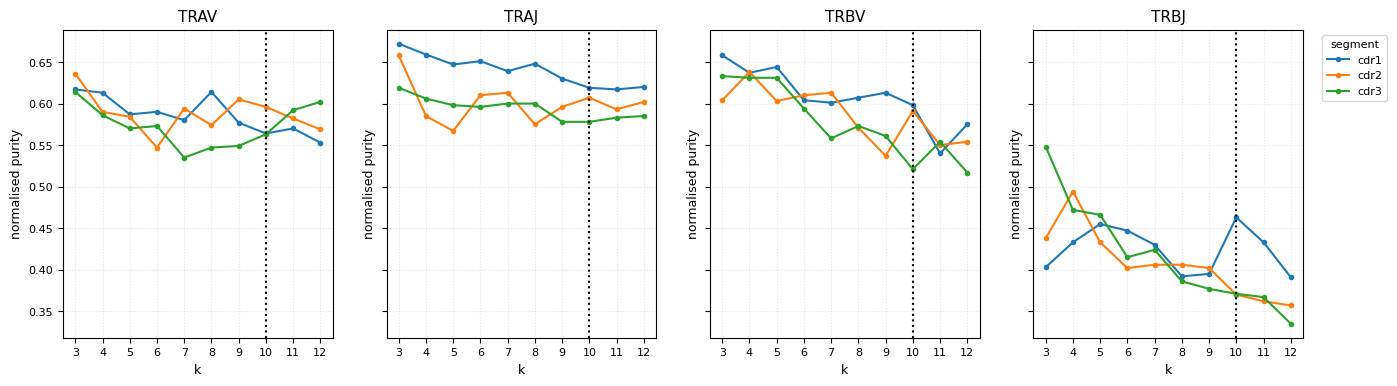

In [93]:
segments_all = ['cdr1', 'cdr2', 'cdr3']
gene_cols    = {'TRA': ['TRAV', 'TRAJ'], 'TRB': ['TRBV', 'TRBJ']}
k_range      = range(3, 13)

results = []
for chain in ['TRA', 'TRB']:
    for seg in segments_all:
        try:
            df_pca = pd.read_pickle(f'pca_exp_{chain}_{seg}.pkl')
        except FileNotFoundError:
            continue

        for gcol in gene_cols[chain]:
            df_valid = df_pca.dropna(subset=[gcol])
            if df_valid[gcol].nunique() < 2:
                continue
            X           = df_valid[['PC1', 'PC2']].values
            gene_labels = df_valid[gcol].values

            for k in k_range:
                cluster_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
                purities = []
                for gene in np.unique(gene_labels):
                    mask = gene_labels == gene
                    if mask.sum() < 2:
                        continue
                    majority_frac = np.bincount(cluster_labels[mask], minlength=k).max() / mask.sum()
                    purities.append(majority_frac)
                purity      = np.mean(purities)
                purity_norm = (purity - 1/k) / (1 - 1/k)
                results.append({'chain': chain, 'segment': seg, 'gene': gcol,
                                 'k': k, 'purity_norm': round(purity_norm, 3)})

df_results = pd.DataFrame(results)

gene_chain = {'TRAV': 'TRA', 'TRAJ': 'TRA', 'TRBV': 'TRB', 'TRBJ': 'TRB'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, gcol in zip(axes, ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']):
    chain = gene_chain[gcol]
    sub   = df_results[(df_results['chain'] == chain) & (df_results['gene'] == gcol)]
    for seg in segments_all:
        seg_data = sub[sub['segment'] == seg]
        if seg_data.empty:
            continue
        ax.plot(seg_data['k'], seg_data['purity_norm'],
                linewidth=1.5, marker='o', markersize=3,
                label=seg)

    ax.set_title(gcol, fontsize=11)
    ax.set_xlabel('k', fontsize=9)
    ax.set_ylabel('normalised purity', fontsize=9)
    ax.set_xticks(list(k_range))
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.axvline(10, color='black', linestyle=':')

# single legend on last subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles=handles, labels=labels,
                bbox_to_anchor=(1.05, 1), loc='upper left',
                fontsize=8, frameon=True, title='segment', title_fontsize=8)



/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_19918/3048436329.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', k)


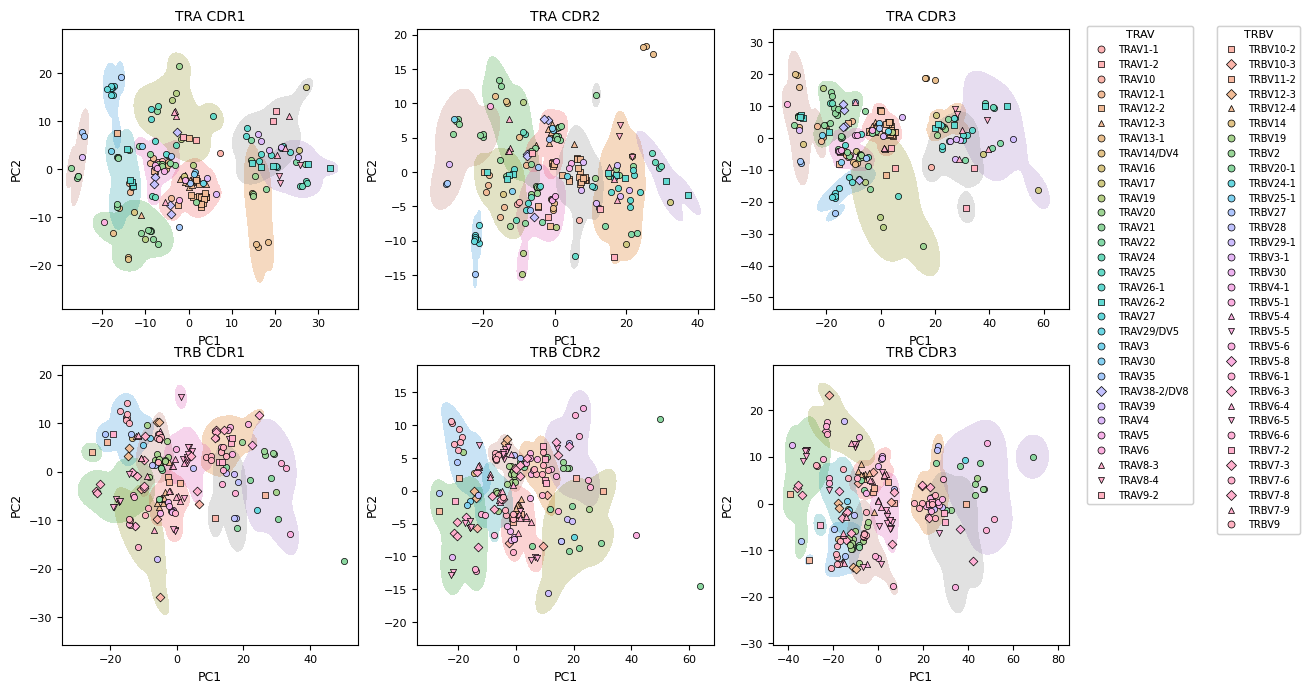

In [120]:
from scipy.optimize import linear_sum_assignment

def align_labels(labels_ref, pdb_ref, labels_other, pdb_other, k):
    """Remap labels_other to best match labels_ref based on shared PDBs."""
    common = list(set(pdb_ref) & set(pdb_other))
    if len(common) < 2:
        return labels_other
    ref_dict   = dict(zip(pdb_ref,   labels_ref))
    other_dict = dict(zip(pdb_other, labels_other))
    r = np.array([ref_dict[p]   for p in common])
    o = np.array([other_dict[p] for p in common])
    overlap = np.zeros((k, k), dtype=int)
    for ri, oi in zip(r, o):
        overlap[oi, ri] += 1
    row_ind, col_ind = linear_sum_assignment(-overlap)
    mapping = np.zeros(k, dtype=int)
    for ri, ci in zip(row_ind, col_ind):
        mapping[ri] = ci
    return mapping[labels_other]


plotly_to_mpl = {
    'circle':        'o',
    'square':        's',
    'diamond':       'D',
    'triangle-up':   '^',
    'triangle-down': 'v',
}

chains     = ['TRA', 'TRB']
cdrs       = ['cdr1', 'cdr2', 'cdr3']
cdr_labels = {'cdr1': 'CDR1', 'cdr2': 'CDR2', 'cdr3': 'CDR3'}
gene_col   = {'TRA': 'TRAV', 'TRB': 'TRBV'}
k          = 10

# first pass: compute all cluster labels
cluster_data = {}
for chain in chains:
    gcol = gene_col[chain]
    for cdr in cdrs:
        df_pca   = pd.read_pickle(f'pca_exp_{chain}_{cdr}.pkl')
        df_valid = df_pca.dropna(subset=[gcol])
        X        = df_valid[['PC1', 'PC2']].values
        labels   = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
        cluster_data[(chain, cdr)] = {
            'labels': labels, 'pdb': df_valid['PDB'].values,
            'X': X, 'df_pca': df_pca,
        }

# align cdr1 and cdr2 to cdr3 (per chain)
for chain in chains:
    ref = cluster_data[(chain, 'cdr3')]
    for cdr in ['cdr1', 'cdr2']:
        other = cluster_data[(chain, cdr)]
        cluster_data[(chain, cdr)]['labels'] = align_labels(
            ref['labels'], ref['pdb'],
            other['labels'], other['pdb'], k
        )

# plot
cmap = cm.get_cmap('tab10', k)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row_i, chain in enumerate(chains):
    gcol = gene_col[chain]
    for col_i, cdr in enumerate(cdrs):
        ax             = axes[row_i, col_i]
        d              = cluster_data[(chain, cdr)]
        df_pca         = d['df_pca']
        X              = d['X']
        cluster_labels = d['labels']

        # KDE per cluster (bottom)
        for c in range(k):
            pts = X[cluster_labels == c]
            if len(pts) < 5:
                continue
            sns.kdeplot(x=pts[:, 0], y=pts[:, 1], ax=ax,
                        fill=True, color=cmap(c), alpha=0.25,
                        thresh=0.1, levels=2, zorder=1)

        # gene scatter (top)
        for gene, grp in df_pca.groupby(gcol, sort=True):
            aes    = mixtcrviz_aes[gcol].get(str(gene), {'color': '#aaaaaa', 'symbol': 'circle'})
            marker = plotly_to_mpl.get(aes['symbol'], 'o')
            ax.scatter(grp['PC1'], grp['PC2'],
                       c=aes['color'], marker=marker, s=20,
                       edgecolors='black', linewidths=0.5, zorder=3)

        ax.set_title(f'{chain} {cdr_labels[cdr]}', fontsize=10)
        ax.set_xlabel('PC1', fontsize=9)
        ax.set_ylabel('PC2', fontsize=9)
        ax.tick_params(labelsize=8)

# gene legends
x_offsets = [0.91, 1.01]
for chain, x_pos in zip(chains, x_offsets):
    gcol   = gene_col[chain]
    df_leg = pd.read_pickle(f'pca_exp_{chain}_cdr3.pkl')
    handles = []
    for gene in sorted(df_leg[gcol].dropna().unique()):
        aes = mixtcrviz_aes[gcol].get(str(gene), {'color': '#aaaaaa', 'symbol': 'circle'})
        handles.append(mlines.Line2D([], [], color=aes['color'],
                                     marker=plotly_to_mpl.get(aes['symbol'], 'o'),
                                     markersize=5, linewidth=0,
                                     markeredgecolor='black', markeredgewidth=0.5,
                                     label=str(gene)))
    leg = fig.legend(handles=handles, title=gcol,
                     bbox_to_anchor=(x_pos, 0.89), loc='upper left',
                     fontsize=7, title_fontsize=8, frameon=True)
    fig.add_artist(leg)

In [128]:
chains = ['TRA', 'TRB']
cdrs   = ['cdr1', 'cdr2', 'cdr3']
k      = 10

anno_cols = ['PDB', 'Epitope', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'CDR3A', 'CDR3B']

rows = []
for chain in chains:
    for cdr in cdrs:
        d              = cluster_data[(chain, cdr)]
        X              = d['X']
        cluster_labels = d['labels']
        pdb_ids        = d['pdb']
        df_anno        = d['df_pca'][anno_cols].drop_duplicates(subset='PDB')

        for c in range(k):
            mask = cluster_labels == c
            pts  = X[mask]
            if len(pts) == 0:
                continue
            centroid  = pts.mean(axis=0)
            dists     = np.linalg.norm(pts - centroid, axis=1)
            closest   = pdb_ids[mask][np.argmin(dists)]
            row_anno  = df_anno[df_anno['PDB'] == closest]
            if row_anno.empty:
                continue
            rows.append({
                'chain':        chain,
                'cdr':          cdr,
                'cluster':      c,
                'n':            mask.sum(),
                'centroid_PC1': centroid[0],
                'centroid_PC2': centroid[1],
                **row_anno.iloc[0][anno_cols].to_dict()
            })

df_centroids = (pd.DataFrame(rows)
                  .sort_values(['chain', 'cdr', 'cluster'])
                  .reset_index(drop=True))

indir      = '../260326_TCR_motif_atlas_exp_structures/pdbs_mhc_align'
outdir     = 'centroids'
os.makedirs(outdir, exist_ok=True)

for _, row in df_centroids.iterrows():
    src      = os.path.join(indir, f"{row['PDB']}.pdb")
    fname    = f"{row['cluster']}_{row['cdr']}{row['chain'][-1]}_{row['PDB']}.pdb"
    dst      = os.path.join(outdir, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print(f"Missing: {src}")

In [129]:
df_centroids

,chain,cdr,cluster,n,centroid_PC1,centroid_PC2,PDB,Epitope,TRAV,TRAJ,TRBV,TRBJ,CDR3A,CDR3B
0,TRA,cdr1,0,47,1.209869,-4.373023,5HYJ,A0201_AQWGPDPAAA,TRAV12-3,TRAJ12,TRBV12-4,TRBJ2-4,CAMRGDSSYKLIF,CASSLWEKLAKNIQYF
1,TRA,cdr1,1,33,-6.776157,0.969355,3MV9,B3501_HPVGEADYFEY,TRAV20,TRAJ58,TRBV9,TRBJ2-2,CAVQDLGTSGSRLTF,CASSARSGELFF
2,TRA,cdr1,2,14,-11.527641,-13.517283,7N2O,B2705_LRVMMLAPF,TRAV21,TRAJ58,TRBV9,TRBJ2-3,CAVLSPVQETSGSRLTF,CASSVGLFSTDTQYF
3,TRA,cdr1,3,7,-25.459469,1.805449,7RK7,A0201_YMDGTMSQV,TRAV4,TRAJ42,TRBV10-3,TRBJ1-3,CLVALNYGGSQGNLIF,CAISPTEEGGLIFPGNTIYF
4,TRA,cdr1,4,8,16.020430,-8.594600,6XCO,DQA10301-DQB10302_GQVELGGGNAVEVCK,TRAV20,TRAJ7,TRBV5-1,TRBJ1-2,CAVQAGGNNRLAF,CASSLERDGYTF
5,TRA,cdr1,5,21,18.499916,5.789513,7T2C,DPA10103-DPB10401_TGLAWEWWRTVY,TRAV4,TRAJ8,TRBV20-1,TRBJ2-7,CLVGDTGFQKLVF,CSARDPGGGGSSYEQYF
6,TRA,cdr1,6,17,24.806709,-0.004284,8PJG,DRB10101_PKYVKQNTLKLAR,TRAV8-4,TRAJ30,TRBV24-1,TRBJ1-2,CAVSEQDDKIIF,CATSDESYGYTF
7,TRA,cdr1,7,9,-17.555517,15.860984,1OGA,A0201_GILGFVFTL,TRAV27,TRAJ42,TRBV19,TRBJ2-7,CAGAGSQGNLIF,CASSSRSSYEQYF
8,TRA,cdr1,8,16,-3.035518,11.191467,8GVG,A2402_RFPLTFGW,TRAV8-3,TRAJ10,TRBV7-9,TRBJ2-5,CAVGFTGGGNKLTF,CASSDRDRVPETQYF
9,TRA,cdr1,9,15,-15.030354,-1.627579,3KPS,B4405_EEYLQAFTY,TRAV26-2,TRAJ52,TRBV7-8,TRBJ2-7,CILPLAGGTSYGKLTF,CASSLGQAYEQYF
